# Task 3: Model Evaluation

Evaluate models using accuracy, precision, recall, F1, and ROC-AUC. Generate confusion matrices and ROC curves.

--- Logistic Regression ---
Accuracy: 0.5910
Precision: 0.5910
Recall: 1.0000
F1 Score: 0.7430
ROC-AUC: 0.5520



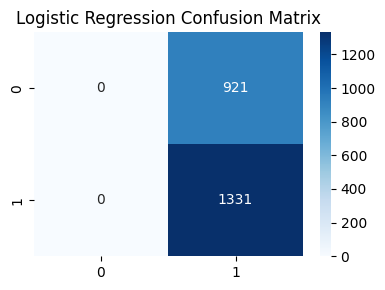

--- Random Forest ---
Accuracy: 0.5959
Precision: 0.5948
Recall: 0.9925
F1 Score: 0.7438
ROC-AUC: 0.5609



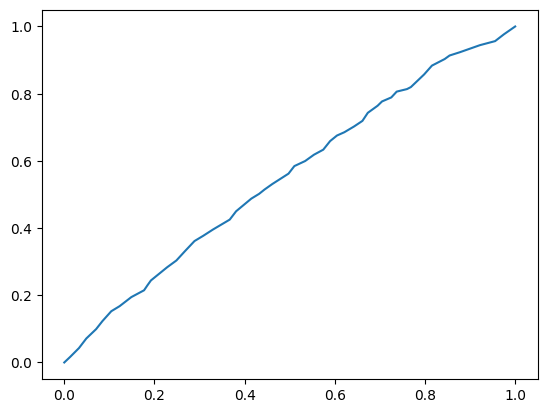

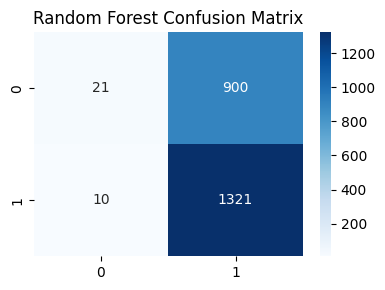

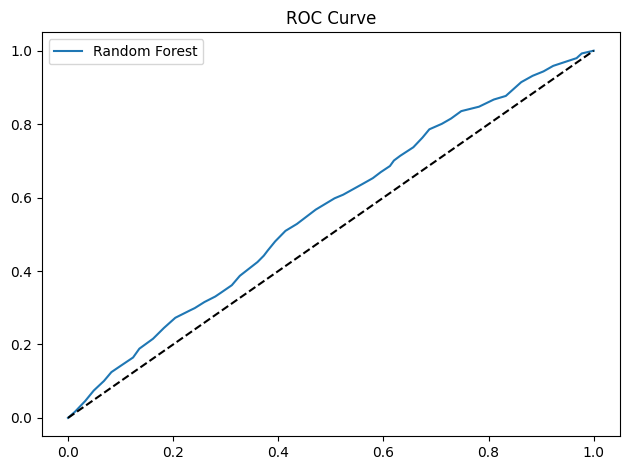

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

df = pd.read_csv('../data/processed/final_features.csv')
features = ['average_age', 'average_caps', 'fifa_ranking', 'recent_tournament_score']
features = [f for f in features if f in df.columns]

X = df[features]
y = df['home_win']
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = joblib.load('scaler.pkl')
lr_model = joblib.load('lr_model.pkl')
rf_model = joblib.load('rf_model.pkl')

X_test_scaled = scaler.transform(X_test)

def evaluate_model(name, model, X, y):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:, 1]
    
    print(f"--- {name} ---")
    print(f"Accuracy: {accuracy_score(y, preds):.4f}")
    print(f"Precision: {precision_score(y, preds):.4f}")
    print(f"Recall: {recall_score(y, preds):.4f}")
    print(f"F1 Score: {f1_score(y, preds):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y, probs):.4f}\n")
    
    cm = confusion_matrix(y, preds)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.tight_layout()
    filename = name.lower().replace(' ', '_')
    plt.savefig(f'cm_{filename}.png')
    plt.show()
    
    fpr, tpr, _ = roc_curve(y, probs)
    plt.plot(fpr, tpr, label=name)

evaluate_model('Logistic Regression', lr_model, X_test_scaled, y_test)
evaluate_model('Random Forest', rf_model, X_test_scaled, y_test)

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.show()
